In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Kaggle usually has PyTorch installed. We just need PyG.
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.0 MB/s eta 0:00:00a 0:00:01


In [3]:
import torch

# 1. Dynamically detect your Kaggle environment's exact versions
torch_version = torch.__version__.split('+')[0]
cuda_version = torch.version.cuda.replace('.', '')
cuda = f"cu{cuda_version}"

url = f"https://data.pyg.org/whl/torch-{torch_version}+{cuda}.html"
print(f"Fetching perfectly matched wheels from:\n{url}\n")

# 2. Wipe the broken generic packages
!pip uninstall -y torch-cluster torch-scatter torch-sparse

# 3. Install the mathematically aligned packages
!pip install torch-scatter torch-sparse torch-cluster -f {url}

Fetching perfectly matched wheels from:
https://data.pyg.org/whl/torch-2.10.0+cu128.html

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 90.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 84.6 MB/s eta 0:00:00ta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 101.9 MB/s eta 0:00:0000:01


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch_geometric.transforms as T
from torch_geometric.datasets import ModelNet
from torch_geometric.loader import DataLoader
from torch_geometric.nn import XConv, global_mean_pool
import matplotlib.pyplot as plt
import numpy as np

# Configuration
BATCH_SIZE = 32
NUM_POINTS = 1024
EPOCHS = 10
LEARNING_RATE = 0.001

CATEGORIES = [
    'airplane', 'bathtub', 'bed', 'bench', 'bookshelf', 'bottle', 'bowl', 'car', 'chair',
    'cone', 'cup', 'curtain', 'desk', 'door', 'dresser', 'flower_pot', 'glass_box',
    'guitar', 'keyboard', 'lamp', 'laptop', 'mantel', 'monitor', 'night_stand',
    'person', 'piano', 'plant', 'radio', 'range_hood', 'sink', 'sofa', 'stairs',
    'stool', 'tent', 'toilet', 'tv_stand', 'vase', 'wardrobe', 'xbox'
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
def plot_3d_point_cloud(points, title):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    ax.scatter(x, y, z, c=z, cmap='viridis', s=10, alpha=0.8, edgecolors='none')
    ax.set_title(title)
    ax.set_axis_off()
    plt.show()

def visualize_initial_data(loader, num_samples=2):
    print("--- Visualizing Initial Training Data ---")
    data = next(iter(loader))
    # Reshape PyG contiguous batch to [Batch, Points, 3]
    points = data.pos.view(-1, NUM_POINTS, 3).cpu().numpy()
    labels = data.y.cpu().numpy()
    for i in range(num_samples):
        class_name = CATEGORIES[labels[i]] if labels[i] < len(CATEGORIES) else str(labels[i])
        plot_3d_point_cloud(points[i], title=f"Initial Data Sample: {class_name}")

def plot_training_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss', marker='o')
    ax1.set_title('PointCNN: Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)

    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc', marker='o')
    ax2.plot(epochs, history['test_acc'], 'g-', label='Test Acc', marker='s')
    ax2.set_title('PointCNN: Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

def visualize_predictions(model, loader, device, num_samples=3):
    print("\n--- Visualizing Final Model Predictions ---")
    model.eval()
    data = next(iter(loader)).to(device)
    labels = data.y.cpu().numpy()
    points_np = data.pos.view(-1, NUM_POINTS, 3).cpu().numpy()

    with torch.no_grad():
        outputs = model(data)
        _, preds = torch.max(outputs.data, 1)
        preds = preds.cpu().numpy()

    for i in range(num_samples):
        true_class = CATEGORIES[labels[i]] if labels[i] < len(CATEGORIES) else str(labels[i])
        pred_class = CATEGORIES[preds[i]] if preds[i] < len(CATEGORIES) else str(preds[i])
        title_color = "green" if true_class == pred_class else "red"

        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(points_np[i, :, 0], points_np[i, :, 1], points_np[i, :, 2], c=points_np[i, :, 2], cmap='viridis', s=10, alpha=0.8)
        ax.set_title(f"True: {true_class} | Pred: {pred_class}", color=title_color, fontweight='bold')
        ax.set_axis_off()
        plt.show()

In [6]:
class PointCNN(nn.Module):
    def __init__(self, num_classes=40):
        super().__init__()
        # XConv applies X-transform to organically order points
        self.conv1 = XConv(in_channels=0, out_channels=48, dim=3, kernel_size=8, hidden_channels=32)
        self.conv2 = XConv(in_channels=48, out_channels=96, dim=3, kernel_size=12, hidden_channels=64, dilation=2)
        self.conv3 = XConv(in_channels=96, out_channels=192, dim=3, kernel_size=16, hidden_channels=128, dilation=2)
        self.conv4 = XConv(in_channels=192, out_channels=384, dim=3, kernel_size=16, hidden_channels=256, dilation=2)

        self.lin1 = nn.Linear(384, 256)
        self.lin2 = nn.Linear(256, 128)
        self.lin3 = nn.Linear(128, num_classes)

    def forward(self, data):
        pos, batch = data.pos, data.batch
        
        x = F.relu(self.conv1(None, pos, batch))
        x = F.relu(self.conv2(x, pos, batch))
        x = F.relu(self.conv3(x, pos, batch))
        x = F.relu(self.conv4(x, pos, batch))

        # Collapse all point features into one global feature per object
        x = global_mean_pool(x, batch)

        x = F.relu(self.lin1(x))
        x = F.relu(self.lin2(x))
        x = F.dropout(x, p=0.5, training=self.training)
        return self.lin3(x)

Extracting data/ModelNet40/ModelNet40.zip
Processing...
Done!


--- Visualizing Initial Training Data ---


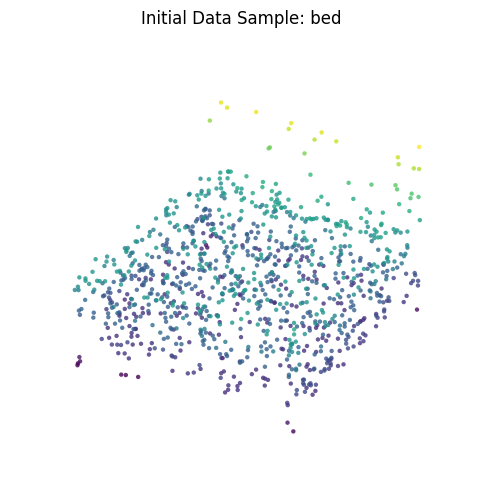

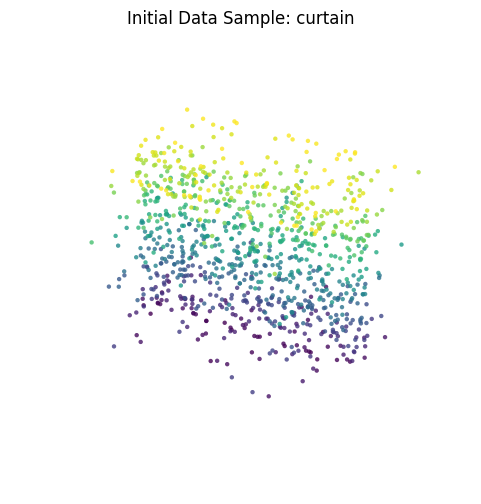

In [7]:
train_transforms = T.Compose([T.SamplePoints(NUM_POINTS), T.NormalizeScale()])
test_transforms = T.Compose([T.SamplePoints(NUM_POINTS), T.NormalizeScale()])

train_dataset = ModelNet(root='data/ModelNet40', name='40', train=True, transform=train_transforms)
test_dataset = ModelNet(root='data/ModelNet40', name='40', train=False, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

visualize_initial_data(train_loader, num_samples=2)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch_geometric.transforms as T
from torch_geometric.datasets import ModelNet
from torch_geometric.loader import DataLoader
from torch_geometric.nn import XConv, global_mean_pool
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
!pip install torch-cluster torch-scatter torch-sparse

In [8]:
model = PointCNN(num_classes=40).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
print("\n--- Starting Training ---")

for epoch in range(EPOCHS):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, data.y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += data.y.size(0)
        train_correct += (predicted == data.y).sum().item()

    train_acc = 100 * train_correct / train_total

    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            test_total += data.y.size(0)
            test_correct += (predicted == data.y).sum().item()

    test_acc = 100 * test_correct / test_total

    history['train_loss'].append(train_loss/len(train_loader))
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")


--- Starting Training ---
Epoch [01/10] | Train Loss: 2.6466 | Train Acc: 28.93% | Test Acc: 44.81%
Epoch [02/10] | Train Loss: 1.7143 | Train Acc: 51.49% | Test Acc: 56.85%
Epoch [03/10] | Train Loss: 1.4329 | Train Acc: 58.11% | Test Acc: 61.75%
Epoch [04/10] | Train Loss: 1.2698 | Train Acc: 62.45% | Test Acc: 66.98%
Epoch [05/10] | Train Loss: 1.1194 | Train Acc: 66.17% | Test Acc: 69.37%
Epoch [06/10] | Train Loss: 1.0208 | Train Acc: 69.46% | Test Acc: 73.42%
Epoch [07/10] | Train Loss: 0.9882 | Train Acc: 69.43% | Test Acc: 73.78%
Epoch [08/10] | Train Loss: 0.9311 | Train Acc: 71.88% | Test Acc: 73.87%
Epoch [09/10] | Train Loss: 0.8574 | Train Acc: 73.74% | Test Acc: 74.88%
Epoch [10/10] | Train Loss: 0.7746 | Train Acc: 75.92% | Test Acc: 78.73%



--- Generating Training Plots ---


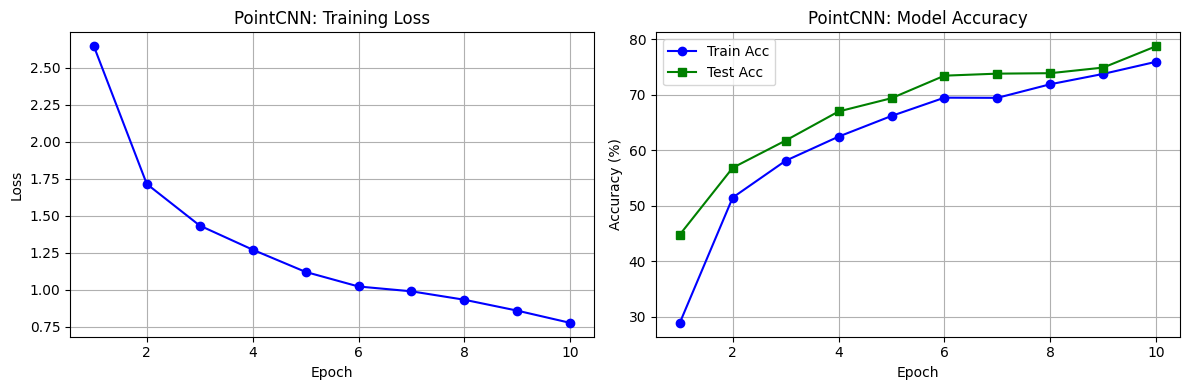


--- Visualizing Final Model Predictions ---


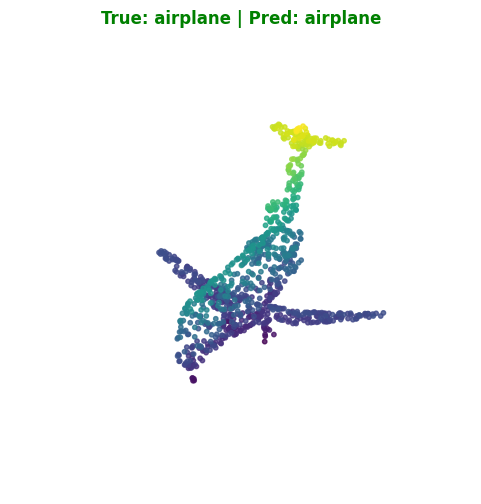

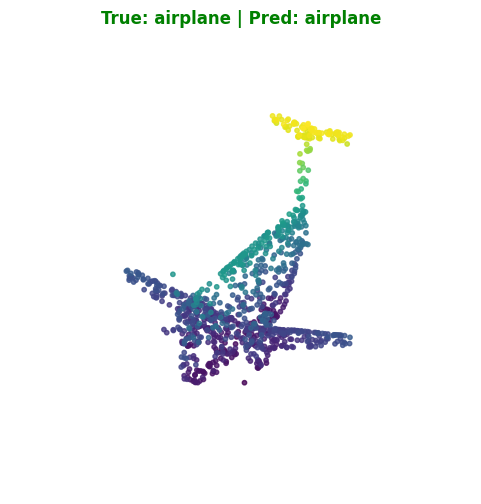

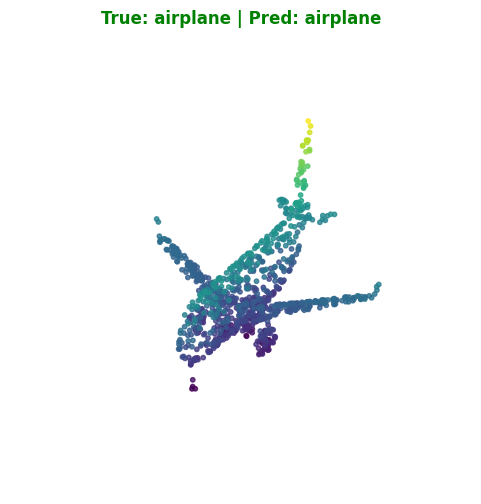

FINAL EVALUATION METRICS (PointCNN)
Overall Accuracy (oA)      : 78.44%
Mean Class Accuracy (mAcc) : 71.53%


(0.7844408427876823, np.float64(0.7152732558139535))

In [9]:
print("\n--- Generating Training Plots ---")
plot_training_curves(history)
visualize_predictions(model, test_loader, device, num_samples=3)

def calculate_classification_metrics(model, test_loader, device, num_classes=40):
    model.eval()
    total_correct = 0
    total_samples = 0
    class_correct = np.zeros(num_classes)
    class_total = np.zeros(num_classes)

    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            labels = data.y

            total_samples += labels.size(0)
            total_correct += (predicted == labels).sum().item()

            for i in range(labels.size(0)):
                label = labels[i].item()
                pred = predicted[i].item()
                class_total[label] += 1
                if label == pred:
                    class_correct[label] += 1

    oA = total_correct / total_samples
    class_accuracies = [class_correct[i] / class_total[i] for i in range(num_classes) if class_total[i] > 0]
    mAcc = np.mean(class_accuracies)

    print("="*40)
    print("FINAL EVALUATION METRICS (PointCNN)")
    print("="*40)
    print(f"Overall Accuracy (oA)      : {oA * 100:.2f}%")
    print(f"Mean Class Accuracy (mAcc) : {mAcc * 100:.2f}%")
    print("="*40)
    return oA, mAcc

calculate_classification_metrics(model, test_loader, device)